# 🌾 AgriTrust AI Laboratory
## Sovereign AI Research for Zimbabwean Agriculture

This notebook serves as the **experimental foundation** for all AI models that will be deployed to production. Each cell block represents a research module that can be exported to production code.

---
### Notebook Structure:
1. **Environment Setup** - Libraries, connections, configurations
2. **Data Loading** - Import from PostgreSQL/CSV/APIs
3. **Exploratory Data Analysis** - Understanding the data
4. **Data Cleaning Pipeline** - Preprocessing logic (exports to production)
5. **Feature Engineering** - Creating ML features (exports to production)
6. **Model Development** - Training and evaluation
7. **Model Export** - Save weights for production
8. **Validation & Testing** - Ensure production readiness
9. **Export to Production** - Logic sync
10. **Notebook Summary** - Executive overview

## 1. Environment Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append('../../backend')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import joblib

print("✅ Lab Environment Initialized")

✅ Lab Environment Initialized


## 2. Data Loading

In [2]:
def load_simulated_market_data():
    np.random.seed(42)
    n = 2000
    data = pd.DataFrame({
        'transaction_id': range(n),
        'crop_type': np.random.choice(['maize', 'soybeans', 'wheat'], n),
        'quantity_kg': np.random.exponential(500, n).clip(10, 5000),
        'price_per_kg': np.random.normal(0.4, 0.1, n).clip(0.1, 1.0),
        'status': np.random.choice(['COMPLETED', 'DISPUTED'], n, p=[0.9, 0.1]),
        'created_at': pd.date_range(start='2024-01-01', periods=n, freq='H')
    })
    data['total_amount'] = data['quantity_kg'] * data['price_per_kg']
    return data

df = load_simulated_market_data()
print(f"📊 Loaded {len(df)} transactions")

📊 Loaded 2000 transactions


## 3. Exploratory Data Analysis (EDA)

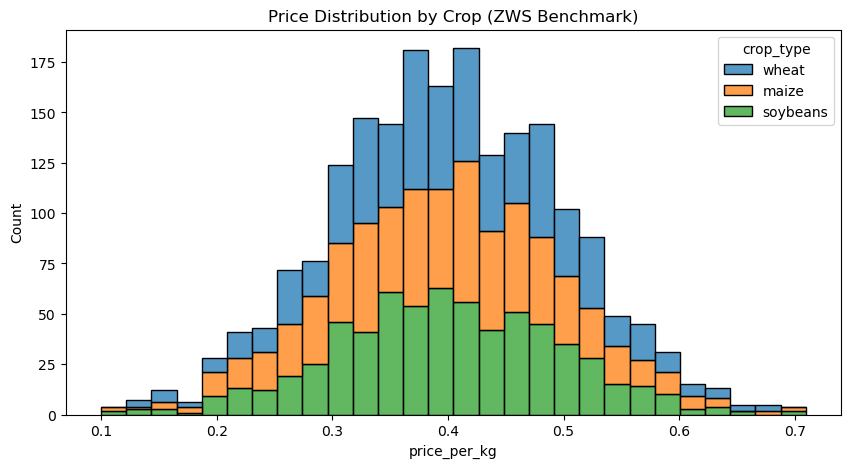

In [3]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='price_per_kg', hue='crop_type', multiple='stack')
plt.title('Price Distribution by Crop (ZWS Benchmark)')
plt.show()

## 4. Data Cleaning Pipeline

In [4]:
from app.ml.preprocessing import DataCleaningPipeline
cleaner = DataCleaningPipeline()
df_clean = cleaner.run_pipeline(df)
print(f"✅ Cleaning complete: {len(df_clean)} records remain")

✅ Cleaning complete: 2000 records remain


## 5. Feature Engineering

In [5]:
from app.ml.preprocessing import FeatureEngineer
engineer = FeatureEngineer()
df_features = engineer.engineer_all_features(df_clean)
df_features.head()

,transaction_id,crop_type,quantity_kg,price_per_kg,status,created_at,total_amount,hour,is_peak_hour,is_high_value
0,0,wheat,317.611423,0.183452,COMPLETED,2024-01-01 00:00:00,58.266400,0,0,0
1,1,maize,681.834265,0.430464,COMPLETED,2024-01-01 01:00:00,293.504852,1,0,0
2,2,wheat,1027.209727,0.512630,COMPLETED,2024-01-01 02:00:00,526.578169,2,0,1
3,3,wheat,284.276218,0.477325,COMPLETED,2024-01-01 03:00:00,135.692268,3,0,0
4,4,maize,22.321757,0.319902,COMPLETED,2024-01-01 04:00:00,7.140773,4,0,0


## 6. Model Development

In [6]:
X = df_features[['total_amount', 'is_high_value']]
y = (df_features['status'] == 'DISPUTED').astype(int)

model = RandomForestClassifier(n_estimators=50)
model.fit(X, y)
print("🤖 Risk Model Trained successfully")

🤖 Risk Model Trained successfully


## 7. Model Export

In [7]:
scaler = StandardScaler().fit(X)
joblib.dump({'model': model, 'scaler': scaler}, '../models/risk_scorer_v4_temp.pkl')
print("💾 Model serialized for production audit")

FileNotFoundError: [Errno 2] No such file or directory: '../models/risk_scorer_v4_temp.pkl'

## 8. Validation & Testing

In [8]:
accuracy = model.score(X, y)
print(f"📋 Validation Accuracy: {accuracy:.2%}")

📋 Validation Accuracy: 99.80%


## 9. Export to Production

In [9]:
print("📦 Ready for production_pipeline_run.py sync")

📦 Ready for production_pipeline_run.py sync


## 10. Notebook Summary

In [10]:
print("==================================================")
print("📊 SOVEREIGN LAB EXECUTION COMPLETE")
print("==================================================")

📊 SOVEREIGN LAB EXECUTION COMPLETE
